In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Mount Google Drive if not already mounted
from google.colab import drive

!ls /content/drive/MyDrive/Colab\ Notebooks/

'EL 3031'     RAGONDIN	        TP2   TP4   TP6  'tp7-projet (1).ipynb'
 Projet_MLS   TP1_Numpy.ipynb   TP3   TP5   TP7


In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks/Projet_MLS/

base_de_donnees.csv	bdd.gsheet  projet_clean.ipynb
base_de_donnees.gsheet	bdd.ipynb   projet.ipynb


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Projet_MLS/base_de_donnees.csv'
#file_path = '/content/drive/MyDrive/Projet_MLS/base_de_donnees.csv'
df = pd.read_csv(file_path)

df.drop(columns=['deathtime'], inplace=True)
df.drop(columns=['discharge_location'], inplace=True)
df.drop(columns=['died_within_admission'], inplace=True)
df.drop(columns=['admittime'], inplace=True)
df.drop(columns=['dischtime'], inplace=True)
df.drop(columns=['hadm_id'], inplace=True)
df.drop(columns=['insurance'], inplace=True)
df.drop(columns=['language'], inplace=True)
df.drop(columns=['marital_status'], inplace=True)
df.drop(columns=['race'], inplace=True)
df.drop(columns=['icd_codes'], inplace=True)
df.drop(columns=['icd_versions'], inplace=True)

df.head()

,subject_id,gender,anchor_age,admission_type,admission_location,los_hours,num_diagnoses,hematocrit,hemoglobin,mch,...,ast,inr,pt,ptt,lactate,ph,po2,pco2,num_lab_tests,hospital_expire_flag
0,10000032,F,52,URGENT,TRANSFER FROM HOSPITAL,18.87,8,37.6,12.7,33.4,...,98.0,1.5,16.6,32.3,NaN,NaN,NaN,NaN,41.0,0
1,10000032,F,52,EW EMER.,EMERGENCY ROOM,24.37,8,35.5,12.4,34.5,...,158.0,1.5,16.3,NaN,NaN,NaN,NaN,NaN,32.0,0
2,10000032,F,52,EW EMER.,EMERGENCY ROOM,53.33,13,34.8,11.9,34.9,...,187.0,1.8,19.5,34.2,NaN,NaN,NaN,NaN,29.0,0
3,10000032,F,52,EW EMER.,EMERGENCY ROOM,42.10,10,34.6,12.1,35.9,...,221.0,1.5,15.8,32.5,NaN,NaN,NaN,NaN,28.0,0
4,10000068,F,19,EU OBSERVATION,EMERGENCY ROOM,7.17,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
print(df.shape)
print(df.info())

(21001, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21001 entries, 0 to 21000
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            21001 non-null  int64  
 1   gender                21001 non-null  object 
 2   anchor_age            21001 non-null  int64  
 3   admission_type        21001 non-null  object 
 4   admission_location    21001 non-null  object 
 5   los_hours             21001 non-null  float64
 6   num_diagnoses         21001 non-null  int64  
 7   hematocrit            14156 non-null  float64
 8   hemoglobin            13812 non-null  float64
 9   mch                   13795 non-null  float64
 10  mchc                  13796 non-null  float64
 11  mcv                   13796 non-null  float64
 12  platelet_count        13911 non-null  float64
 13  rbc                   13796 non-null  float64
 14  rdw                   13793 non-null  float64
 15  wbc    

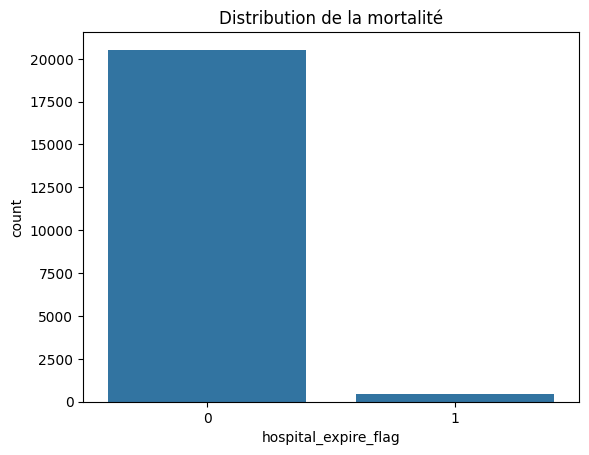

In [ ]:
sns.countplot(x="hospital_expire_flag", data=df)
plt.title("Distribution de la mortalité")
plt.show()

In [ ]:
# Séparation features / target
target = "hospital_expire_flag"

# Colonnes
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

# retirer target des num_cols
num_cols.remove(target)

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [ ]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Shape of preprocessed training data:", X_train_preprocessed.shape)
print("Shape of preprocessed testing data:", X_test_preprocessed.shape)

Shape of preprocessed training data: (16800, 59)
Shape of preprocessed testing data: (4201, 59)


### Vérification des valeurs manquantes après prétraitement

Nous allons vérifier que `X_train_preprocessed` et `X_test_preprocessed` (les données que les modèles utilisent) ne contiennent plus de valeurs manquantes.

In [ ]:
print("Nombre de valeurs manquantes dans X_train_preprocessed :", np.isnan(X_train_preprocessed).sum())
print("Nombre de valeurs manquantes dans X_test_preprocessed :", np.isnan(X_test_preprocessed).sum())

Nombre de valeurs manquantes dans X_train_preprocessed : 0
Nombre de valeurs manquantes dans X_test_preprocessed : 0


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Pipeline pour la régression logistique avec SMOTE
model_lr_smote = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Entraîner le modèle
model_lr_smote.fit(X_train, y_train)

# Prédictions et évaluation
y_pred_lr_smote = model_lr_smote.predict(X_test)
y_proba_lr_smote = model_lr_smote.predict_proba(X_test)[:, 1]

print("--- Logistic Regression avec SMOTE ---")
print("ROC AUC LR SMOTE:", roc_auc_score(y_test, y_proba_lr_smote))
print(classification_report(y_test, y_pred_lr_smote))


--- Logistic Regression avec SMOTE ---
ROC AUC LR SMOTE: 0.9108976976473915
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      4108
           1       0.10      0.77      0.18        93

    accuracy                           0.85      4201
   macro avg       0.55      0.81      0.55      4201
weighted avg       0.97      0.85      0.90      4201



### Matrice de Confusion Regression Logistique

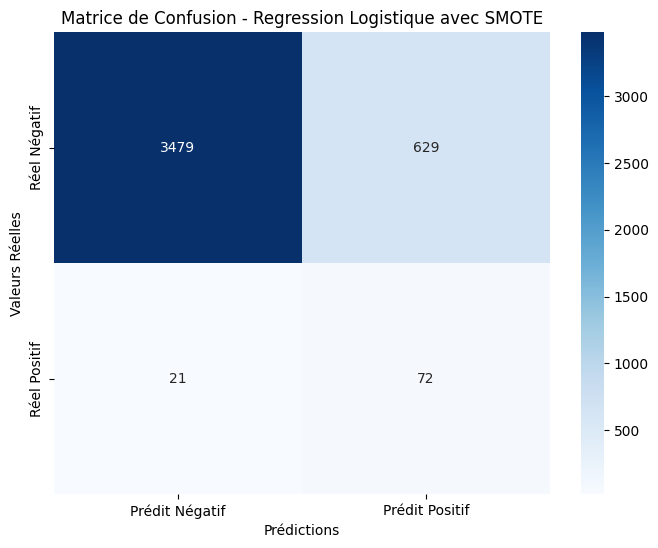

In [ ]:
cm_lr_smote = confusion_matrix(y_test, y_pred_lr_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_smote, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Prédit Négatif', 'Prédit Positif'],
            yticklabels=['Réel Négatif', 'Réel Positif'])
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.title('Matrice de Confusion - Regression Logistique avec SMOTE')
plt.show()

In [ ]:
# L'idée ici est de définir une grille d'hyperparamètres pour améliorer la regression logistique

param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}

In [18]:
# ici on initialise le GridSearchCV avec la regression logistique et en intégrant la grille d'hyperparamètres

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Initialiser GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=model_lr_smote,
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2
)

# Entraîner le GridSearchCV
grid_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['subject_id',
                                                                          'anchor_age',
                                                                          'los_hours',
                                                                          'num_diagnoses',
                                                                          'hematocrit',
                                                                          'hemoglobin',
                                                                          'mch',
                                                                          'mchc',
                                                                          'mcv',
                                                                          'pla...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'admission_type',
                                                                          'admission_location'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear', 'saga']},
             scoring='roc_auc', verbose=2)

In [ ]:
print("Meilleurs paramètres pour Logistic Regression:", grid_search_lr.best_params_)
print("Meilleur score ROC AUC pour Logistic Regression:", grid_search_lr.best_score_)

In [ ]:
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test)
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_tuned, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Prédit Négatif', 'Prédit Positif'],
            yticklabels=['Réel Négatif', 'Réel Positif'])
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.title('Matrice de Confusion - Logistic Regression Optimisée avec SMOTE')
plt.show()

In [ ]:
# Pipeline pour Random Forest avec SMOTE
model_rf_smote = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Entraîner le modèle
model_rf_smote.fit(X_train, y_train)

# Prédictions et évaluation
y_pred_rf_smote = model_rf_smote.predict(X_test)
y_proba_rf_smote = model_rf_smote.predict_proba(X_test)[:, 1]

print("\n--- Random Forest avec SMOTE ---")
print("ROC AUC RF SMOTE:", roc_auc_score(y_test, y_proba_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))